In [3]:
# Import Libraries
import numpy as np 
import pandas as pd 

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

In [4]:
# reading the dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')
# check the shape of the data
data.shape

(150500, 13)

In [19]:
# display top 5 rows of data

data.head()

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location,PdId
0,120058272,WEAPON LAWS,POSS OF PROHIBITED WEAPON,Friday,01/29/2016 12:00:00 AM,11:00,SOUTHERN,"ARREST, BOOKED",800 Block of BRYANT ST,-122.403405,37.775421,"(37.775420706711, -122.403404791479)",12005827212120
1,120058272,WEAPON LAWS,"FIREARM, LOADED, IN VEHICLE, POSSESSION OR USE",Friday,01/29/2016 12:00:00 AM,11:00,SOUTHERN,"ARREST, BOOKED",800 Block of BRYANT ST,-122.403405,37.775421,"(37.775420706711, -122.403404791479)",12005827212168
2,141059263,WARRANTS,WARRANT ARREST,Monday,04/25/2016 12:00:00 AM,14:59,BAYVIEW,"ARREST, BOOKED",KEITH ST / SHAFTER AV,-122.388856,37.729981,"(37.7299809672996, -122.388856204292)",14105926363010
3,160013662,NON-CRIMINAL,LOST PROPERTY,Tuesday,01/05/2016 12:00:00 AM,23:50,TENDERLOIN,NONE,JONES ST / OFARRELL ST,-122.412971,37.785788,"(37.7857883766888, -122.412970537591)",16001366271000
4,160002740,NON-CRIMINAL,LOST PROPERTY,Friday,01/01/2016 12:00:00 AM,00:30,MISSION,NONE,16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214668, -122.419671780296)",16000274071000


In [20]:
# display last 5 rows of data

data.tail()

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location,PdId
150495,161061000,ASSAULT,BATTERY,Friday,12/30/2016 12:00:00 AM,21:01,PARK,NONE,OAK ST / STANYAN ST,-122.453982,37.771428,"(37.7714278595913, -122.453981622365)",16106100004134
150496,176000742,NON-CRIMINAL,LOST PROPERTY,Friday,12/30/2016 12:00:00 AM,08:00,CENTRAL,NONE,JACKSON ST / SANSOME ST,-122.401857,37.796626,"(37.7966261239618, -122.401857374739)",17600074271000
150497,176000758,LARCENY/THEFT,PETTY THEFT OF PROPERTY,Thursday,12/29/2016 12:00:00 AM,20:00,CENTRAL,NONE,PINE ST / TAYLOR ST,-122.412269,37.790673,"(37.7906727649886, -122.41226909106)",17600075806372
150498,176000764,LARCENY/THEFT,GRAND THEFT OF PROPERTY,Friday,12/30/2016 12:00:00 AM,10:00,CENTRAL,NONE,200 Block of STOCKTON ST,-122.406659,37.788275,"(37.7882745285785, -122.406658711008)",17600076406374
150499,179002868,OTHER OFFENSES,"FRAUDULENT GAME OR TRICK, OBTAINING MONEY OR P...",Friday,12/02/2016 12:00:00 AM,14:00,SOUTHERN,NONE,800 Block of BRYANT ST,-122.403405,37.775421,"(37.775420706711, -122.403404791479)",17900286809024


In [21]:
# basic statistics the data

data.describe()

,IncidntNum,X,Y,PdId
count,1.505000e+05,150500.000000,150500.000000,1.505000e+05
mean,1.616440e+08,-122.423599,37.768921,1.616440e+13
std,5.535976e+06,0.026210,0.023637,5.535976e+11
min,1.135121e+07,-122.513642,37.707922,1.135121e+12
25%,1.603283e+08,-122.434036,37.756486,1.603283e+13
50%,1.606541e+08,-122.416903,37.775421,1.606541e+13
75%,1.609764e+08,-122.406605,37.785063,1.609764e+13
max,9.910090e+08,-122.365565,37.819975,9.910090e+13


In [22]:
# checking if there are any null values

data.isnull().sum()

IncidntNum    0
Category      0
Descript      0
DayOfWeek     0
Date          0
Time          0
PdDistrict    1
Resolution    0
Address       0
X             0
Y             0
Location      0
PdId          0
dtype: int64

In [33]:
# Information of data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150500 entries, 0 to 150499
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   IncidntNum  150500 non-null  int64         
 1   Category    150500 non-null  object        
 2   Descript    150500 non-null  object        
 3   DayOfWeek   150500 non-null  object        
 4   Date        150500 non-null  datetime64[ns]
 5   Time        150500 non-null  object        
 6   PdDistrict  150500 non-null  object        
 7   Resolution  150500 non-null  object        
 8   Address     150500 non-null  object        
 9   X           150500 non-null  float64       
 10  Y           150500 non-null  float64       
 11  Location    150500 non-null  object        
 12  PdId        150500 non-null  int64         
 13  Month       150500 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(8)
memory usage: 15.5+ MB


In [23]:
# filling the missing value in PdDistrict using the mode values

data['PdDistrict'].fillna(data['PdDistrict'].mode()[0], inplace = True)

data.isnull().any().any()

False

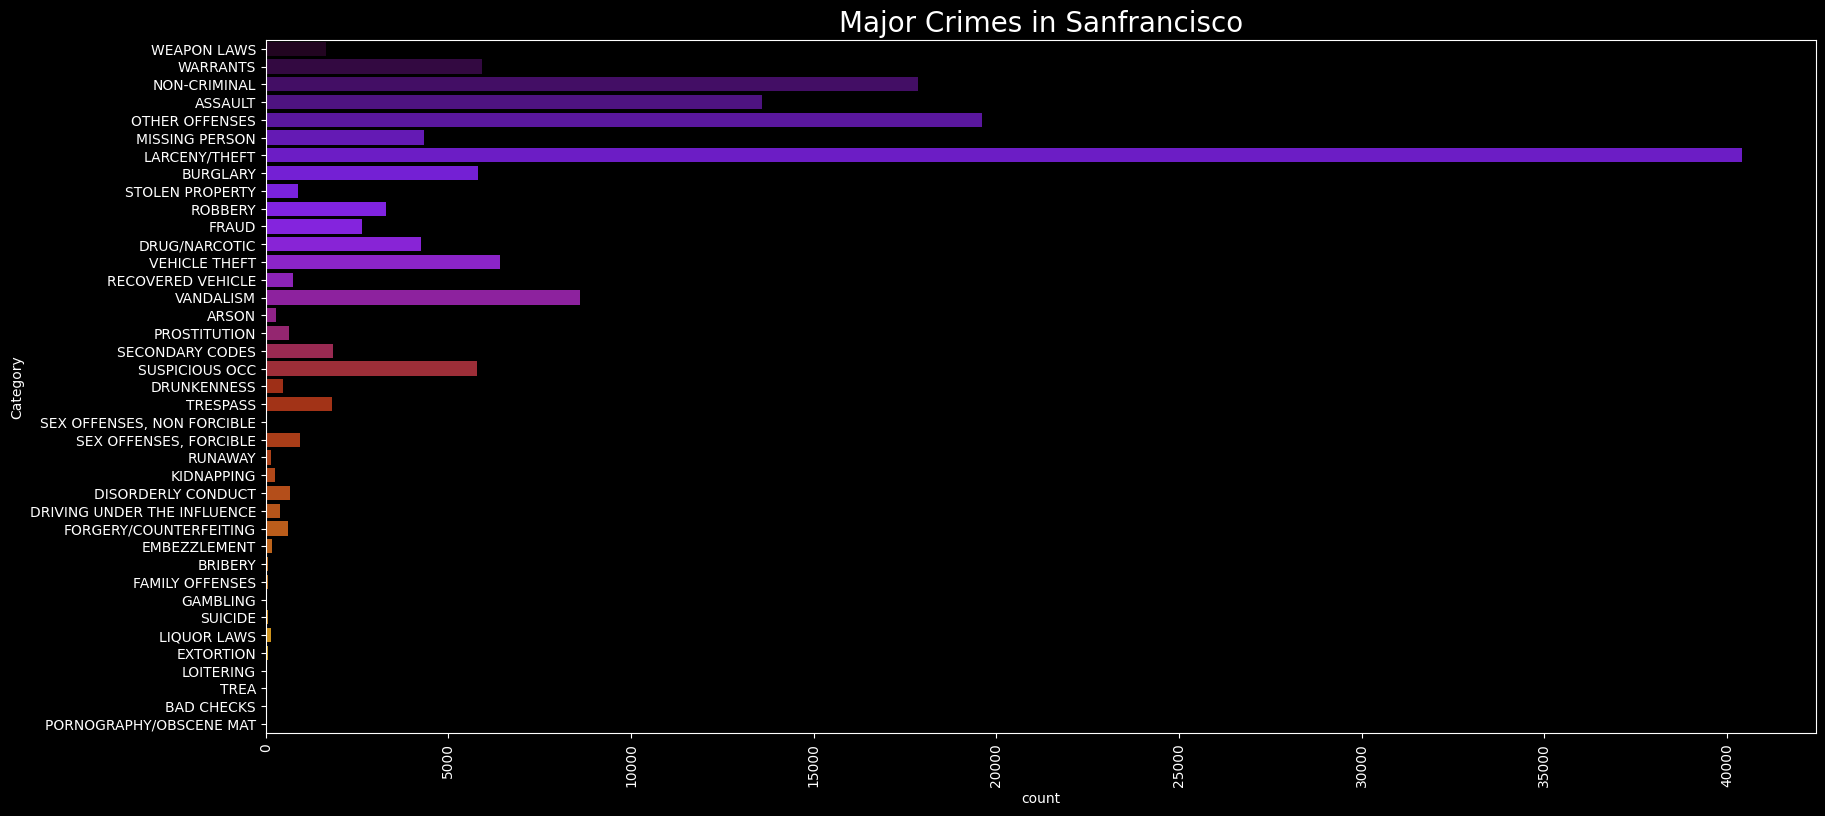

In [24]:
# different categories of crime

plt.rcParams['figure.figsize'] = (20, 9)
plt.style.use('dark_background')

sns.countplot(data['Category'], palette = 'gnuplot')
plt.title('Major Crimes in Sanfrancisco', fontweight = 30, fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

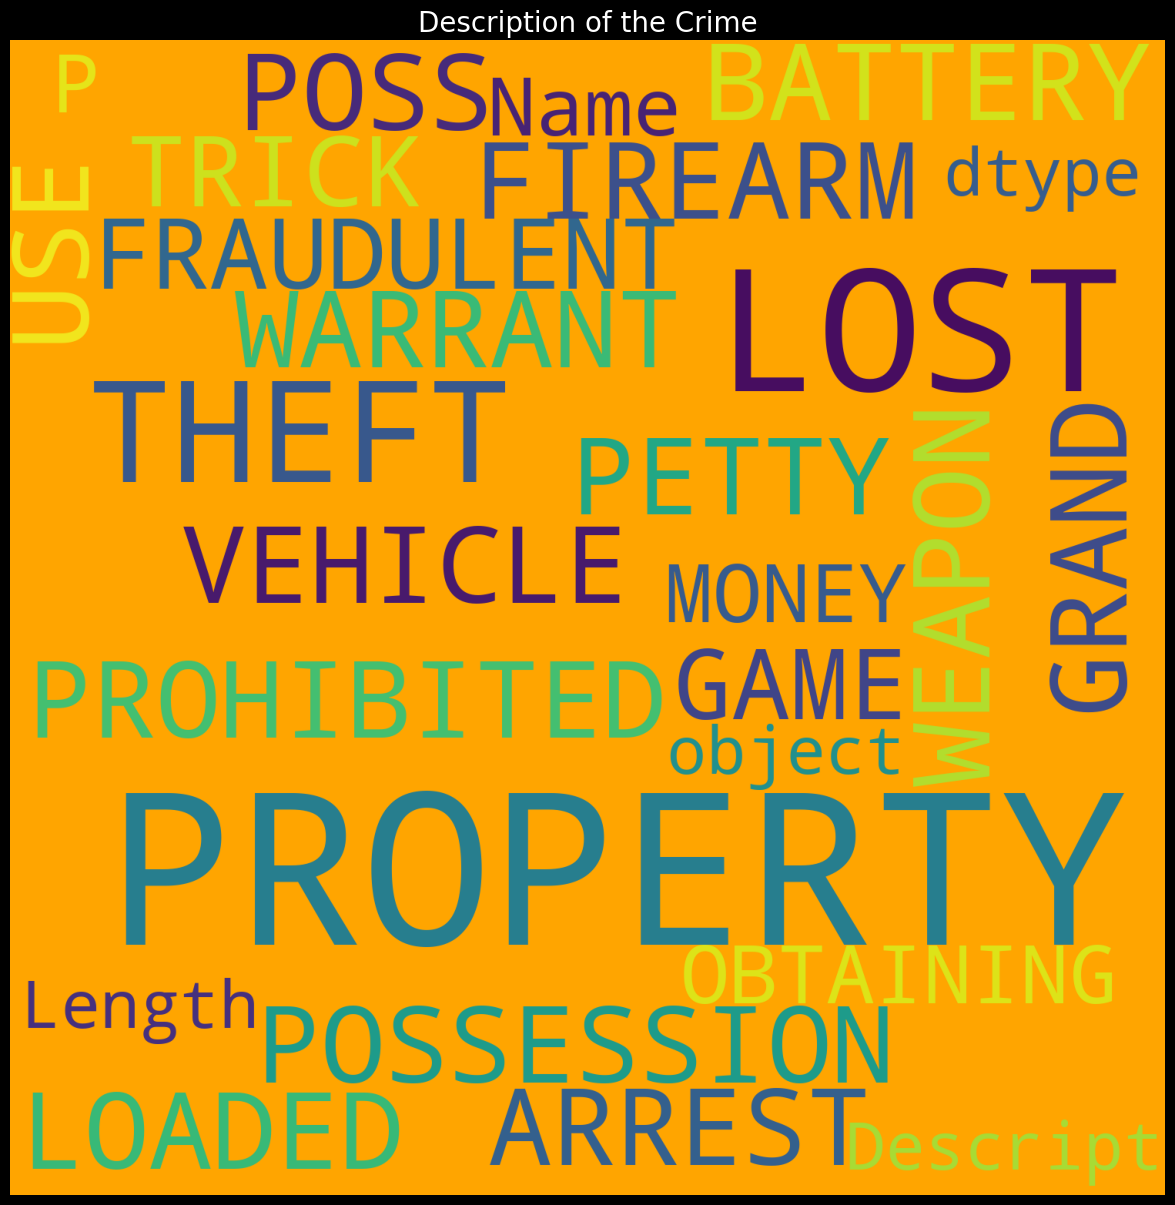

In [26]:
# description of the crime

from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (15, 15)
plt.style.use('fast')

wc = WordCloud(background_color = 'orange', width = 1500, height = 1500).generate(str(data['Descript']))
plt.title('Description of the Crime', fontsize = 20)
plt.imshow(wc)
plt.axis('off')
plt.show()

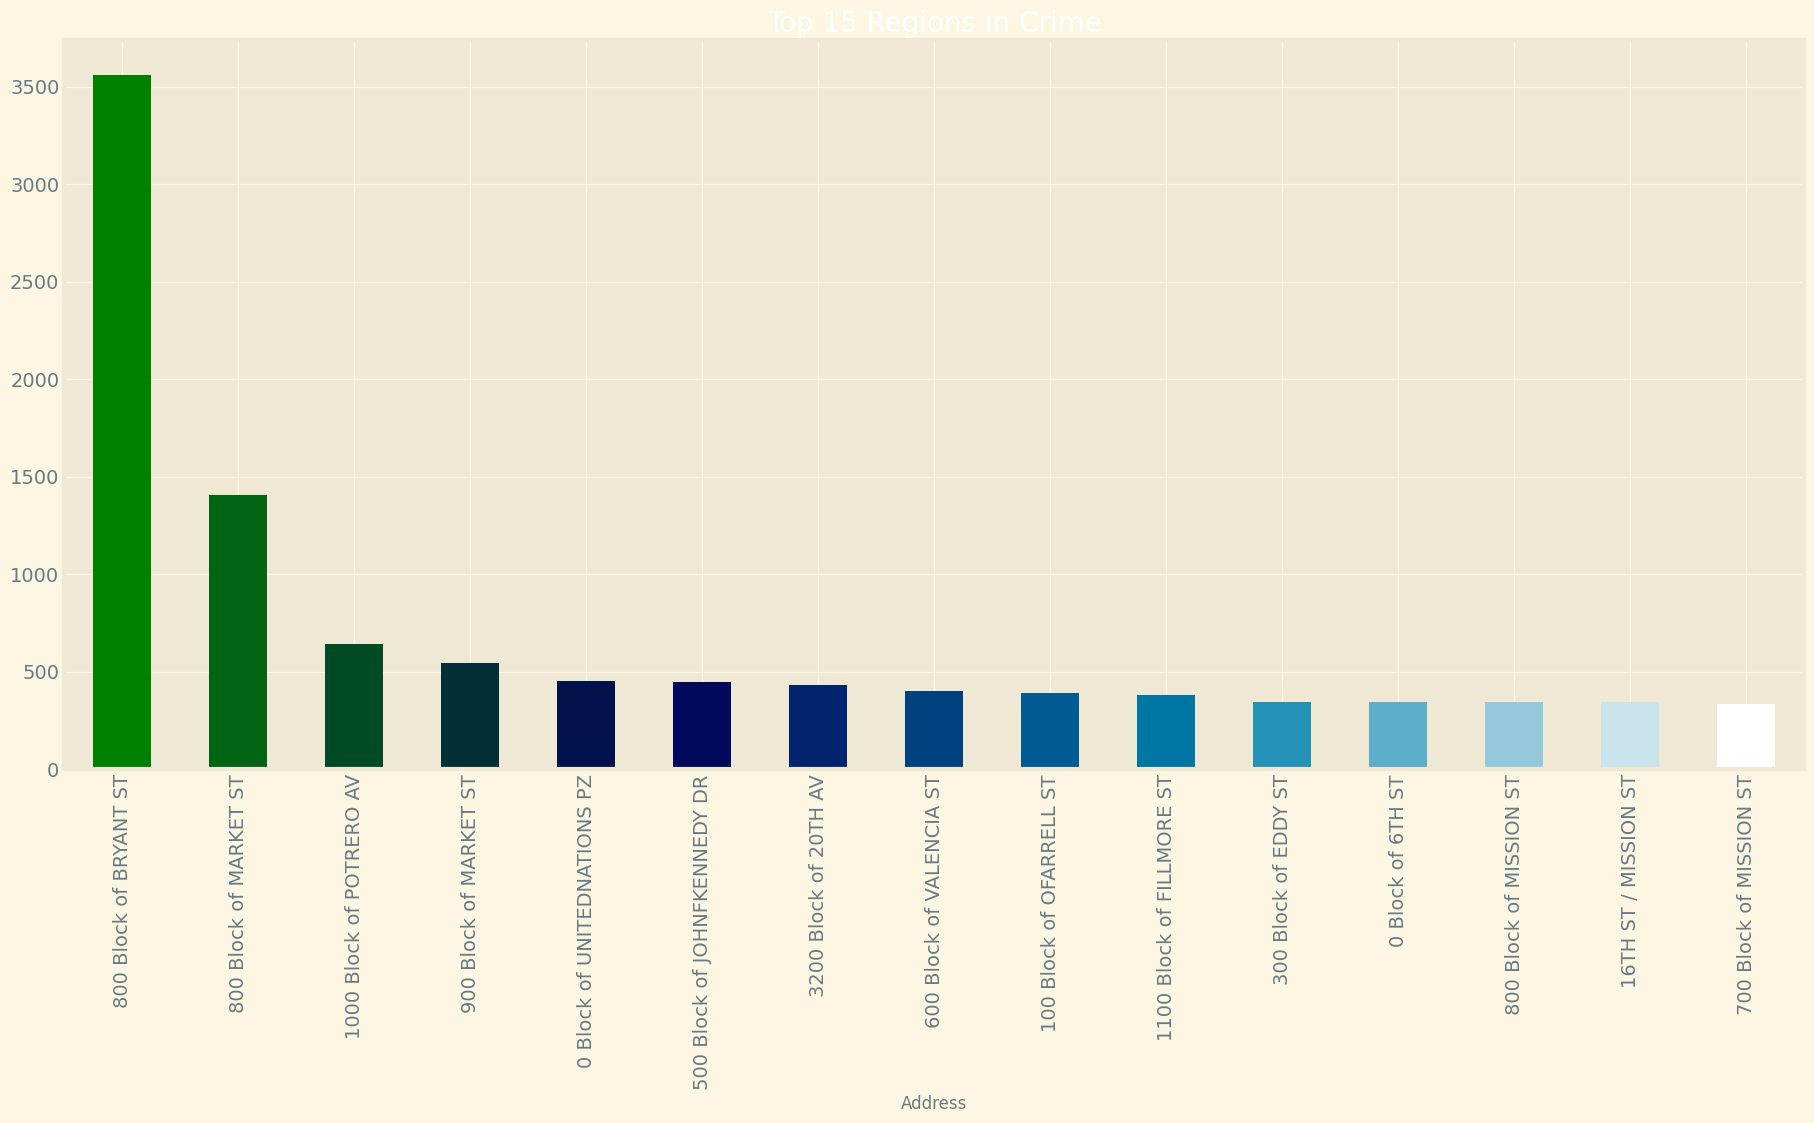

In [28]:
# Regions with count of crimes

plt.rcParams['figure.figsize'] = (20, 9)
plt.style.use('Solarize_Light2')

color = plt.cm.ocean(np.linspace(0, 1, 15))
data['Address'].value_counts().head(15).plot.bar(color = color)

plt.title('Top 15 Regions in Crime',fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

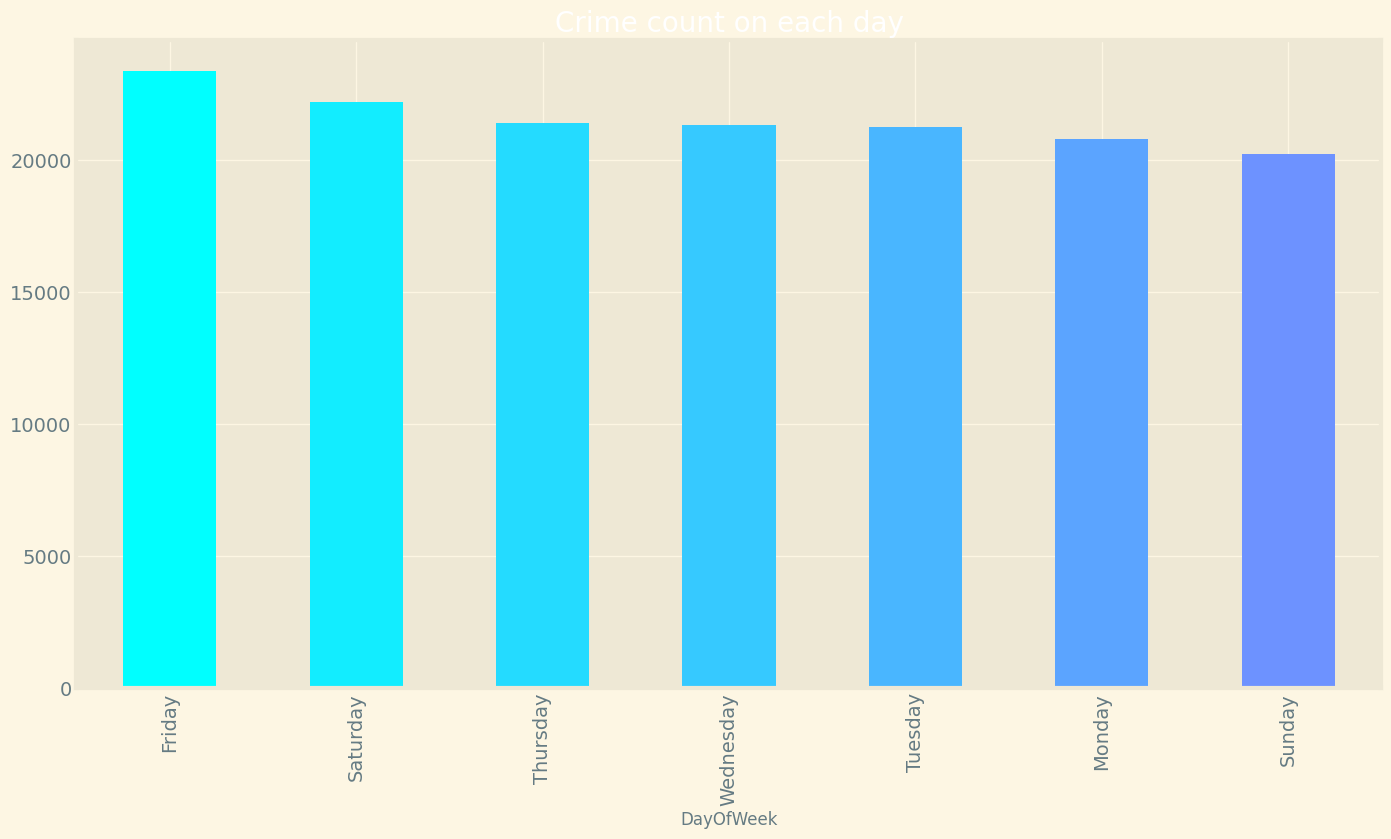

In [30]:
# Regions with count of crimes

import seaborn as sns

color = plt.cm.cool(np.linspace(0, 1, 15))
data['DayOfWeek'].value_counts().head(15).plot.bar(color = color, figsize = (15, 8))

plt.title('Crime count on each day',fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

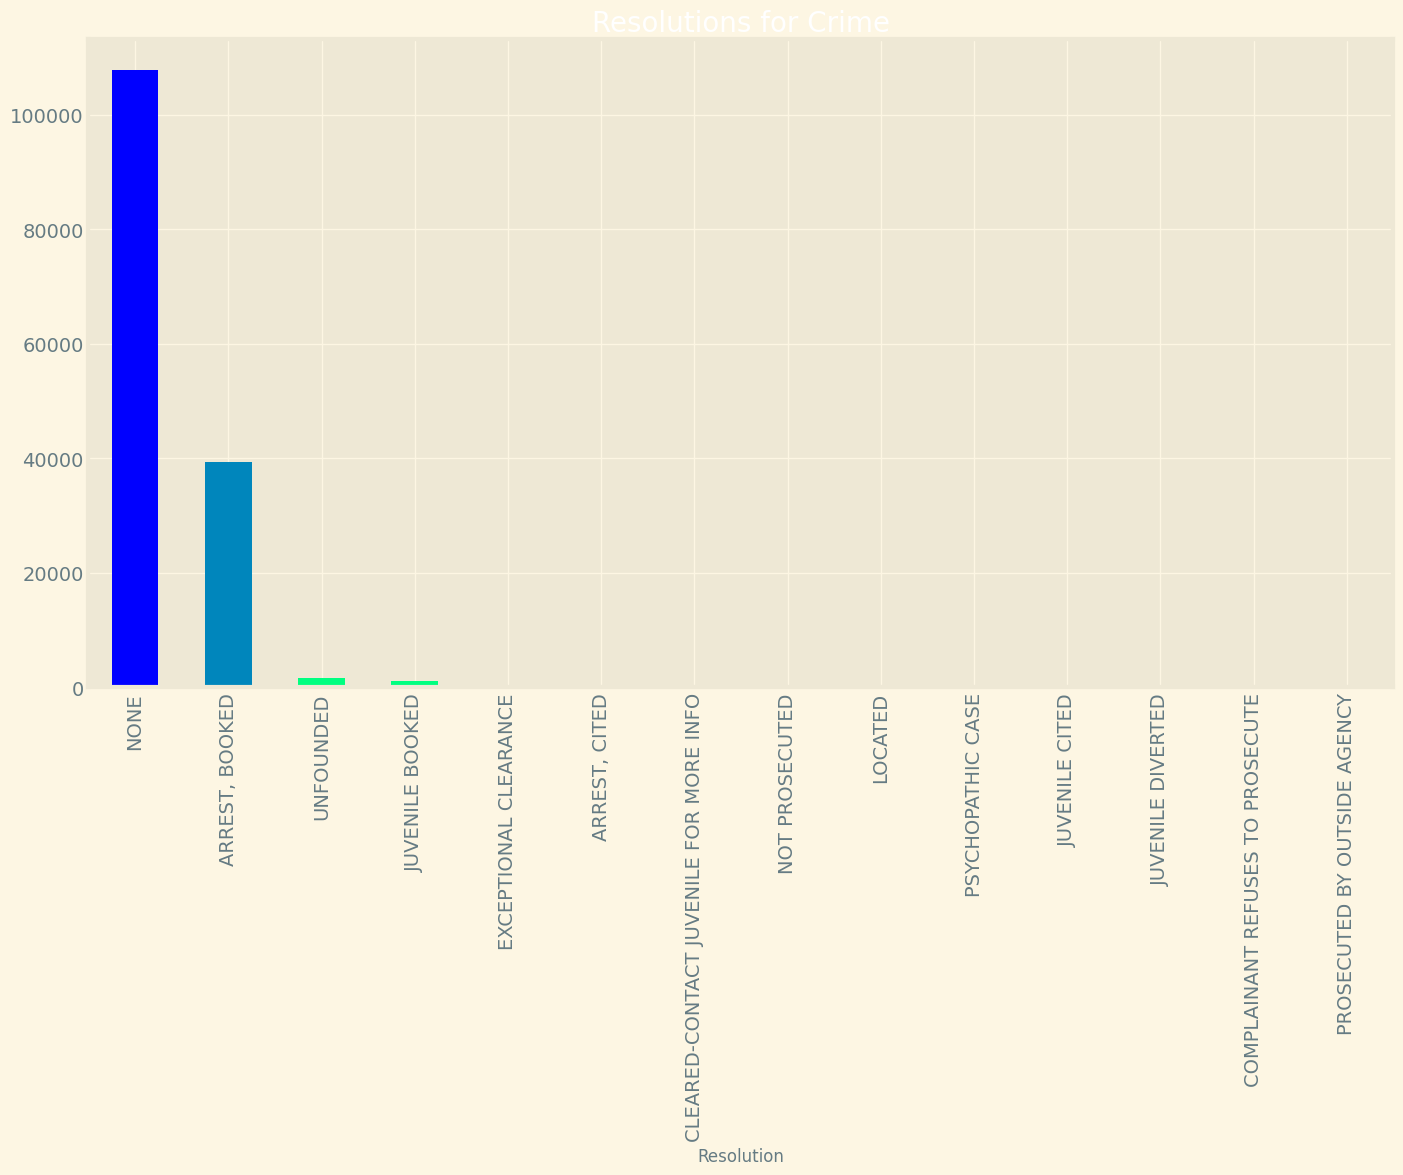

In [31]:
# Regions with count of crimes

import seaborn as sns

color = plt.cm.winter(np.linspace(0, 10, 20))
data['Resolution'].value_counts().plot.bar(color = color, figsize = (15, 8))

plt.title('Resolutions for Crime',fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

In [39]:
# import pandas as pd
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.pipeline import make_pipeline
# from sklearn.metrics import classification_report
# import joblib
# import numpy as np

# # Load the dataset
# data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# # Data Preprocessing
# data.dropna(subset=['PdDistrict'], inplace=True)  # Drop rows with missing PdDistrict
# data = data[data['Category'].notna()]  # Drop rows with missing Category

# # Time Series Preparation
# data['Date'] = pd.to_datetime(data['Date'])
# data.set_index('Date', inplace=True)
# daily_crime_counts = data['Category'].resample('D').count()

# # ARIMA Model for Forecasting
# def forecast_future_crimes(daily_crime_counts, periods=30):
#     model = ARIMA(daily_crime_counts, order=(5, 1, 0))
#     model_fit = model.fit()
#     forecast = model_fit.forecast(steps=periods)
#     return forecast  # Return forecasted values

# future_crime_forecast = forecast_future_crimes(daily_crime_counts)

# # Extract features and labels
# X = data['Descript']  # Text data
# y = data['Category']  # Labels

# # Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Create a pipeline with TF-IDF vectorizer and SVM classifier
# pipeline = make_pipeline(
#     TfidfVectorizer(stop_words='english', max_features=1000),  # Vectorize text data
#     SVC(kernel='linear', C=1)  # Linear SVM
# )

# # Train the model
# pipeline.fit(X_train, y_train)

# # Evaluate the model
# y_pred = pipeline.predict(X_test)
# print(classification_report(y_test, y_pred))

# # Save the model
# joblib.dump(pipeline, 'svm_model_with_forecast.joblib')

In [40]:
# import pandas as pd
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.pipeline import make_pipeline
# import joblib

# # Load the dataset
# data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# # Data Preprocessing
# data.dropna(subset=['PdDistrict'], inplace=True)  # Drop rows with missing PdDistrict
# data = data[data['Category'].notna()]  # Drop rows with missing Category

# # Time Series Preparation
# data['Date'] = pd.to_datetime(data['Date'])
# data.set_index('Date', inplace=True)
# daily_crime_counts = data['Category'].resample('D').count()

# # ARIMA Model for Forecasting
# def forecast_future_crimes(daily_crime_counts, periods=30):
#     model = ARIMA(daily_crime_counts, order=(5, 1, 0))
#     model_fit = model.fit()
#     forecast = model_fit.forecast(steps=periods)
#     return forecast  # Return forecasted values

# future_crime_forecast = forecast_future_crimes(daily_crime_counts)

# # Load the saved SVM model
# svm_model = joblib.load('svm_model_with_forecast.joblib')

# # Define functions for prediction
# def identify_patterns(description):
#     # This function would ideally use a trained model to identify patterns
#     # For simplicity, let's return a placeholder
#     return "Pattern Identification not yet implemented"

# def predict_risks(description):
#     # Use the loaded SVM model to predict crime category based on description
#     category_prediction = svm_model.predict([description])[0]
#     return category_prediction

# def receive_recommendations(description):
#     # This function would ideally provide recommendations based on the description
#     # For simplicity, let's return a placeholder
#     return "Recommendations not yet implemented"

# def process_crime_details_with_forecast(description):
#     patterns = identify_patterns(description)
#     risks = predict_risks(description)
#     recommendations = receive_recommendations(description)
#     forecast = future_crime_forecast.tolist()  # Convert forecast to list for easy handling
    
#     return patterns, risks, recommendations, forecast

# # Example usage
# crime_description = "A suspect broke into a residential property through a window and stole electronics."
# patterns, risks, recommendations, forecast = process_crime_details_with_forecast(crime_description)

# print("Identify Patterns:", patterns)
# print("Predict Risks:", risks)
# print("Receive Recommendations:", recommendations)
# print("Future Crime Forecast:", forecast)


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import joblib

# Load the dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# Data Preprocessing
data.dropna(subset=['PdDistrict'], inplace=True)  # Drop rows with missing PdDistrict
data = data[data['Category'].notna()]  # Drop rows with missing Category

data = data.sample(1000)

# Prepare text data for classification
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['Descript'])
y = data['Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM Model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Save the model
# joblib.dump(svm_model, 'svm_model.joblib')

# Print classification report
from sklearn.metrics import classification_report
y_pred = svm_model.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred))


SVM Classification Report:
                             precision    recall  f1-score   support

                      ARSON       1.00      1.00      1.00         1
                    ASSAULT       0.88      1.00      0.94        15
                   BURGLARY       1.00      0.90      0.95        10
         DISORDERLY CONDUCT       1.00      1.00      1.00         2
DRIVING UNDER THE INFLUENCE       0.50      1.00      0.67         1
              DRUG/NARCOTIC       1.00      1.00      1.00         5
                DRUNKENNESS       0.00      0.00      0.00         1
     FORGERY/COUNTERFEITING       0.00      0.00      0.00         1
                      FRAUD       1.00      0.67      0.80         3
                 KIDNAPPING       0.00      0.00      0.00         1
              LARCENY/THEFT       0.98      1.00      0.99        55
                LIQUOR LAWS       0.00      0.00      0.00         1
             MISSING PERSON       1.00      1.00      1.00        10
      

C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [42]:
import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from statsmodels.tsa.arima.model import ARIMA

# Load the SVM model
svm_model = joblib.load('svm_model.joblib')

# Load and prepare the dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# Time Series Preparation for Future Crime Forecast
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
daily_crime_counts = data['Category'].resample('D').count()

# ARIMA Model for Forecasting Future Crimes
def forecast_future_crimes(daily_crime_counts, periods=5):
    model = ARIMA(daily_crime_counts, order=(5, 1, 0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=periods)
    return forecast

future_crime_forecast = forecast_future_crimes(daily_crime_counts)

# Load and prepare vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
vectorizer.fit(data['Descript'].fillna(''))  # Fit vectorizer on existing data descriptions

# Define recommendations
recommendations = {
    'LARCENY/THEFT': 'Check surveillance footage, increase patrol in the area.',
    'OTHER OFFENSES': 'Investigate specific details of the offense.',
    'NON-CRIMINAL': 'Verify details and ensure no criminal activity is involved.',
    'ASSAULT': 'Collect medical reports, identify witnesses, increase patrols.',
    'VANDALISM': 'Check for CCTV footage, increase neighborhood watch.',
    'VEHICLE THEFT': 'Verify vehicle details, check for nearby security footage.',
    'WARRANTS': 'Locate the individual, ensure proper documentation.',
    'BURGLARY': 'Investigate break-in points, interview witnesses.',
    'SUSPICIOUS OCC': 'Monitor the area, increase patrols.',
    'MISSING PERSON': 'Check nearby hospitals, interview acquaintances.',
    'DRUG/NARCOTIC': 'Conduct surveillance, increase anti-drug operations.',
    'ROBBERY': 'Review security footage, track stolen items.',
    'FRAUD': 'Verify transaction details, interview involved parties.',
    'SECONDARY CODES': 'Verify the context of the secondary code.',
    'TRESPASS': 'Increase patrols in the area, investigate repeat offenders.',
    'WEAPON LAWS': 'Ensure proper registration of weapons, investigate further.',
    'SEX OFFENSES, FORCIBLE': 'Coordinate with victim services, gather evidence.',
    'STOLEN PROPERTY': 'Track down stolen items, interview suspects.',
    'RECOVERED VEHICLE': 'Investigate recovery details, check for related crimes.',
    'DISORDERLY CONDUCT': 'Investigate the incident, check for public disturbances.',
    'PROSTITUTION': 'Monitor the area, verify legality.',
    'FORGERY/COUNTERFEITING': 'Investigate the source of forged documents.',
    'DRUNKENNESS': 'Ensure the individual receives appropriate help.',
    'DRIVING UNDER THE INFLUENCE': 'Conduct sobriety tests, handle legal proceedings.',
    'ARSON': 'Investigate the cause of the fire, check for suspicious activities.',
    'KIDNAPPING': 'Coordinate with other agencies, search for the victim.',
    'EMBEZZLEMENT': 'Investigate financial transactions, interview involved parties.',
    'LIQUOR LAWS': 'Ensure compliance with liquor regulations.',
    'RUNAWAY': 'Coordinate with family, search for the individual.',
    'SUICIDE': 'Coordinate with mental health services, investigate circumstances.',
    'BRIBERY': 'Investigate financial transactions, interview involved parties.',
    'EXTORTION': 'Gather evidence, interview the victim.',
    'FAMILY OFFENSES': 'Investigate family dynamics, ensure victim safety.',
    'LOITERING': 'Increase patrols, ensure public areas are monitored.',
    'SEX OFFENSES, NON FORCIBLE': 'Coordinate with victim services, gather evidence.',
    'BAD CHECKS': 'Investigate the source of the bad checks, interview suspects.',
    'GAMBLING': 'Monitor illegal gambling activities, gather evidence.',
    'PORNOGRAPHY/OBSCENE MAT': 'Investigate the source, gather evidence.',
    'TREA': 'Investigate the nature of the treasonous act, gather evidence.'
}

# Define the prediction function
def process_crime_details(description):
    # Vectorize description
    description_vec = vectorizer.transform([description])

    # Predict crime category
    category_svm = svm_model.predict(description_vec)[0]
    
    # Get recommendations
    rec_svm = recommendations.get(category_svm, 'Recommendation not available.')
    
    # Forecast-related crimes
    def related_crimes_from_forecast(forecast):
        related_crimes = {
            'High': ['LARCENY/THEFT', 'VEHICLE THEFT', 'BURGLARY'],
            'Medium': ['ASSAULT', 'VANDALISM', 'ROBBERY'],
            'Low': ['DISORDERLY CONDUCT', 'PROSTITUTION', 'DRUNKENNESS']
        }
        average_forecast = np.mean(forecast)
        if average_forecast > 430:
            return related_crimes['High']
        elif average_forecast > 400:
            return related_crimes['Medium']
        else:
            return related_crimes['Low']
    
    forecast_related_crimes = related_crimes_from_forecast(future_crime_forecast)

    return {
        'Patterns': "Pattern Identification not yet implemented",
        'Predict Risks': category_svm,
        'Receive Recommendations': rec_svm,
        'Future Crime Forecast': forecast_related_crimes
    }

# Example usage
crime_description = "A suspect broke into a residential property through a window and stole electronics."
results = process_crime_details(crime_description)

print("Identify Patterns:", results['Patterns'])
print("Predict Risks:", results['Predict Risks'])
print("Receive Recommendations:", results['Receive Recommendations'])
print("Future Crime Forecast:", results['Future Crime Forecast'])

Identify Patterns: Pattern Identification not yet implemented
Predict Risks: NON-CRIMINAL
Receive Recommendations: Verify details and ensure no criminal activity is involved.
Future Crime Forecast: ['ASSAULT', 'VANDALISM', 'ROBBERY']


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import joblib

# Load the dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# Data Preprocessing
data.dropna(subset=['PdDistrict'], inplace=True)  # Drop rows with missing PdDistrict
data = data[data['Category'].notna()]  # Drop rows with missing Category

data = data.sample(1000)

# Prepare text data for classification
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['Descript'])
y = data['Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Save the model
# joblib.dump(knn_model, 'knn_model.joblib')

# Print classification report
from sklearn.metrics import classification_report
y_pred = knn_model.predict(X_test)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred))

KNN Classification Report:
                        precision    recall  f1-score   support

               ASSAULT       0.86      0.86      0.86        14
               BRIBERY       0.00      0.00      0.00         1
              BURGLARY       1.00      0.80      0.89         5
         DRUG/NARCOTIC       1.00      1.00      1.00         7
          EMBEZZLEMENT       0.00      0.00      0.00         1
FORGERY/COUNTERFEITING       0.00      0.00      0.00         1
                 FRAUD       1.00      0.67      0.80         3
         LARCENY/THEFT       0.95      1.00      0.97        53
        MISSING PERSON       0.75      1.00      0.86         6
          NON-CRIMINAL       0.95      0.87      0.91        23
        OTHER OFFENSES       0.84      0.95      0.89        22
               ROBBERY       0.75      1.00      0.86         3
               RUNAWAY       0.00      0.00      0.00         2
       SECONDARY CODES       1.00      0.67      0.80         3
SEX OFFENSES

C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [8]:
import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from statsmodels.tsa.arima.model import ARIMA

# Load the SVM model
svm_model = joblib.load('knn_model.joblib')

# Load and prepare the dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# Time Series Preparation for Future Crime Forecast
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
daily_crime_counts = data['Category'].resample('D').count()

# ARIMA Model for Forecasting Future Crimes
def forecast_future_crimes(daily_crime_counts, periods=5):
    model = ARIMA(daily_crime_counts, order=(5, 1, 0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=periods)
    return forecast

future_crime_forecast = forecast_future_crimes(daily_crime_counts)

# Load and prepare vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
vectorizer.fit(data['Descript'].fillna(''))  # Fit vectorizer on existing data descriptions

# Define recommendations
recommendations = {
    'LARCENY/THEFT': 'Check surveillance footage, increase patrol in the area.',
    'OTHER OFFENSES': 'Investigate specific details of the offense.',
    'NON-CRIMINAL': 'Verify details and ensure no criminal activity is involved.',
    'ASSAULT': 'Collect medical reports, identify witnesses, increase patrols.',
    'VANDALISM': 'Check for CCTV footage, increase neighborhood watch.',
    'VEHICLE THEFT': 'Verify vehicle details, check for nearby security footage.',
    'WARRANTS': 'Locate the individual, ensure proper documentation.',
    'BURGLARY': 'Investigate break-in points, interview witnesses.',
    'SUSPICIOUS OCC': 'Monitor the area, increase patrols.',
    'MISSING PERSON': 'Check nearby hospitals, interview acquaintances.',
    'DRUG/NARCOTIC': 'Conduct surveillance, increase anti-drug operations.',
    'ROBBERY': 'Review security footage, track stolen items.',
    'FRAUD': 'Verify transaction details, interview involved parties.',
    'SECONDARY CODES': 'Verify the context of the secondary code.',
    'TRESPASS': 'Increase patrols in the area, investigate repeat offenders.',
    'WEAPON LAWS': 'Ensure proper registration of weapons, investigate further.',
    'SEX OFFENSES, FORCIBLE': 'Coordinate with victim services, gather evidence.',
    'STOLEN PROPERTY': 'Track down stolen items, interview suspects.',
    'RECOVERED VEHICLE': 'Investigate recovery details, check for related crimes.',
    'DISORDERLY CONDUCT': 'Investigate the incident, check for public disturbances.',
    'PROSTITUTION': 'Monitor the area, verify legality.',
    'FORGERY/COUNTERFEITING': 'Investigate the source of forged documents.',
    'DRUNKENNESS': 'Ensure the individual receives appropriate help.',
    'DRIVING UNDER THE INFLUENCE': 'Conduct sobriety tests, handle legal proceedings.',
    'ARSON': 'Investigate the cause of the fire, check for suspicious activities.',
    'KIDNAPPING': 'Coordinate with other agencies, search for the victim.',
    'EMBEZZLEMENT': 'Investigate financial transactions, interview involved parties.',
    'LIQUOR LAWS': 'Ensure compliance with liquor regulations.',
    'RUNAWAY': 'Coordinate with family, search for the individual.',
    'SUICIDE': 'Coordinate with mental health services, investigate circumstances.',
    'BRIBERY': 'Investigate financial transactions, interview involved parties.',
    'EXTORTION': 'Gather evidence, interview the victim.',
    'FAMILY OFFENSES': 'Investigate family dynamics, ensure victim safety.',
    'LOITERING': 'Increase patrols, ensure public areas are monitored.',
    'SEX OFFENSES, NON FORCIBLE': 'Coordinate with victim services, gather evidence.',
    'BAD CHECKS': 'Investigate the source of the bad checks, interview suspects.',
    'GAMBLING': 'Monitor illegal gambling activities, gather evidence.',
    'PORNOGRAPHY/OBSCENE MAT': 'Investigate the source, gather evidence.',
    'TREA': 'Investigate the nature of the treasonous act, gather evidence.'
}

# Define the prediction function
def process_crime_details(description):
    # Vectorize description
    description_vec = vectorizer.transform([description])

    # Predict crime category
    category_svm = svm_model.predict(description_vec)[0]
    
    # Get recommendations
    rec_svm = recommendations.get(category_svm, 'Recommendation not available.')
    
    # Forecast-related crimes
    def related_crimes_from_forecast(forecast):
        related_crimes = {
            'High': ['LARCENY/THEFT', 'VEHICLE THEFT', 'BURGLARY'],
            'Medium': ['ASSAULT', 'VANDALISM', 'ROBBERY'],
            'Low': ['DISORDERLY CONDUCT', 'PROSTITUTION', 'DRUNKENNESS']
        }
        average_forecast = np.mean(forecast)
        if average_forecast > 430:
            return related_crimes['High']
        elif average_forecast > 400:
            return related_crimes['Medium']
        else:
            return related_crimes['Low']
    
    forecast_related_crimes = related_crimes_from_forecast(future_crime_forecast)

    return {
        'Patterns': "Pattern Identification not yet implemented",
        'Predict Risks': category_svm,
        'Receive Recommendations': rec_svm,
        'Future Crime Forecast': forecast_related_crimes
    }

# Example usage
crime_description = "An illegal gambling operation was shut down by authorities after a tip from an anonymous source."
results = process_crime_details(crime_description)

print("Identify Patterns:", results['Patterns'])
print("Predict Risks:", results['Predict Risks'])
print("Receive Recommendations:", results['Receive Recommendations'])
print("Future Crime Forecast:", results['Future Crime Forecast'])

C:\Users\0860\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.5.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\0860\AppData\Local\Temp\ipykernel_14416\3513205038.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


Identify Patterns: Pattern Identification not yet implemented
Predict Risks: GAMBLING
Receive Recommendations: Monitor illegal gambling activities, gather evidence.
Future Crime Forecast: ['ASSAULT', 'VANDALISM', 'ROBBERY']


In [8]:
data['Category'].value_counts()

Category
LARCENY/THEFT                  40409
OTHER OFFENSES                 19599
NON-CRIMINAL                   17866
ASSAULT                        13577
VANDALISM                       8589
VEHICLE THEFT                   6419
WARRANTS                        5914
BURGLARY                        5802
SUSPICIOUS OCC                  5782
MISSING PERSON                  4338
DRUG/NARCOTIC                   4243
ROBBERY                         3299
FRAUD                           2635
SECONDARY CODES                 1841
TRESPASS                        1812
WEAPON LAWS                     1658
SEX OFFENSES, FORCIBLE           940
STOLEN PROPERTY                  882
RECOVERED VEHICLE                736
DISORDERLY CONDUCT               658
PROSTITUTION                     641
FORGERY/COUNTERFEITING           619
DRUNKENNESS                      465
DRIVING UNDER THE INFLUENCE      378
ARSON                            286
KIDNAPPING                       257
EMBEZZLEMENT                 

In [3]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import joblib
# Load your dataset
data = pd.read_csv('Police_Department_Incidents_-_Previous_Year__2016_.csv')

# Label Encode the 'Category' column
label_encoder = LabelEncoder()
data['Category_Encoded'] = label_encoder.fit_transform(data['Category'])

# Save the label encoder for later use
joblib.dump(label_encoder, 'label_encoder.joblib')

['label_encoder.joblib']